In [1]:
import os
import time
import numpy as np
import joblib, json
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\krish\Desktop\STProject\notebooks


In [3]:
# Load the data prepared in the preprocessing notebook
X_train = pd.read_csv('../dataset/X_train.csv')
X_test = pd.read_csv('../dataset/X_test.csv')
y_train = pd.read_csv('../dataset/y_train.csv')['Status'] # Target is 'Status'
y_test = pd.read_csv('../dataset/y_test.csv')['Status']

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train default rate:", y_train.mean().round(4))

Train: (58622, 60) Test: (14656, 60)
Train default rate: 0.5


In [10]:
model_specs = {
    'Linear Regression': (
        LinearRegression(),
        {'fit_intercept': [True, False]},
        False
    ),
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]},
        False
    ),
    'Decision Tree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {'max_depth': [5, 10, 15], 'min_samples_leaf': [5, 10]},
        False
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=1),
        {'n_estimators': [100, 200], 'max_depth': [10, 15], 'min_samples_leaf': [1, 5]},
        False
    ),
    'Linear SVM': (
        LinearSVC(class_weight='balanced', max_iter=5000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]},
        False
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
        True # Uses sample weights
    ),
}

In [11]:
# Compute sample weights for algorithms that don't have 'class_weight' built-in (like GBM)
gb_sample_weights = compute_sample_weight('balanced', y_train)

results = []
fitted_models = {}
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Keep n_jobs=2 to balance speed and memory usage
SEARCH_N_JOBS = 2

for name, (estimator, param_grid, needs_sample_weight) in model_specs.items():
    n_combos = len(list(__import__('itertools').product(*param_grid.values())))
    print(f"Grid searching {name}... ({n_combos} combinations x 3 folds)")
    t0 = time.time()

    grid = GridSearchCV(
        estimator, param_grid,
        scoring='roc_auc', cv=cv_strategy,
        n_jobs=SEARCH_N_JOBS, verbose=0
    )

    if needs_sample_weight:
        grid.fit(X_train, y_train, sample_weight=gb_sample_weights)
    else:
        grid.fit(X_train, y_train)

    search_time = time.time() - t0
    best_model = grid.best_estimator_
    fitted_models[name] = best_model

    print(f"  best params: {grid.best_params_}")
    print(f"  best CV ROC-AUC: {grid.best_score_:.4f}  (search took {search_time:.1f}s)")

    # Handle continuous predictions for Linear/Poly Regression
    if hasattr(best_model, 'predict_proba'):
        scores = best_model.predict_proba(X_test)[:, 1]
        preds = best_model.predict(X_test)
    elif hasattr(best_model, 'decision_function'):
        scores = best_model.decision_function(X_test)
        preds = best_model.predict(X_test)
    else:
        scores = best_model.predict(X_test)
        preds = (scores >= 0.5).astype(int) # Thresholding for Regression models

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, scores),
        'Fit Time (s)': round(search_time, 2),
        'Best Params': grid.best_params_,
    })

Grid searching Linear Regression... (2 combinations x 3 folds)


c:\Users\krish\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(


  best params: {'fit_intercept': True}
  best CV ROC-AUC: nan  (search took 0.5s)
Grid searching Logistic Regression... (4 combinations x 3 folds)
  best params: {'C': 10}
  best CV ROC-AUC: 0.8370  (search took 3.1s)
Grid searching Decision Tree... (6 combinations x 3 folds)
  best params: {'max_depth': 15, 'min_samples_leaf': 10}
  best CV ROC-AUC: 0.8638  (search took 3.0s)
Grid searching Random Forest... (8 combinations x 3 folds)
  best params: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 200}
  best CV ROC-AUC: 0.8853  (search took 80.5s)
Grid searching Linear SVM... (4 combinations x 3 folds)
  best params: {'C': 10}
  best CV ROC-AUC: 0.8328  (search took 10.5s)
Grid searching Gradient Boosting... (4 combinations x 3 folds)
  best params: {'learning_rate': 0.1, 'n_estimators': 200}
  best CV ROC-AUC: 0.8875  (search took 140.3s)


In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Create a 20,000-row representative subsample to save RAM
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=20000, stratify=y_train, random_state=42
)

# ==========================================
# 1. KNN Tuning & Fitting
# ==========================================
print("Tuning KNN on 20,000-row subsample...")
knn_t0 = time.time()
knn_grid = GridSearchCV(
    KNeighborsClassifier(n_jobs=1),
    {'n_neighbors': [5, 15, 25], 'weights': ['uniform', 'distance']},
    scoring='roc_auc', cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=2
)
knn_grid.fit(X_sub, y_sub)

# Final fit on full data for KNN
final_knn = KNeighborsClassifier(**knn_grid.best_params_, n_jobs=-1)
final_knn.fit(X_train, y_train)
knn_fit_time = time.time() - knn_t0

fitted_models['KNN'] = final_knn
knn_preds = final_knn.predict(X_test)
knn_scores = final_knn.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, knn_preds),
    'Precision': precision_score(y_test, knn_preds, zero_division=0),
    'Recall': recall_score(y_test, knn_preds, zero_division=0),
    'F1': f1_score(y_test, knn_preds, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, knn_scores),
    'Fit Time (s)': round(knn_fit_time, 2),
    'Best Params': knn_grid.best_params_,
})
print(f"KNN fit completed in {knn_fit_time:.1f}s")


# ==========================================
# 2. Polynomial Regression Tuning & Fitting
# ==========================================
print("\nTuning & Fitting Polynomial Regression on 20,000-row subsample...")
poly_t0 = time.time()
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# FIX: Removed scoring='roc_auc' because LinearRegression lacks predict_proba
poly_grid = GridSearchCV(
    poly_pipe,
    {'lr__fit_intercept': [True, False]},
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1 
)

poly_grid.fit(X_sub, y_sub)
final_poly = poly_grid.best_estimator_
poly_fit_time = time.time() - poly_t0

fitted_models['Polynomial Regression'] = final_poly

# For evaluation, we treat the raw output as continuous scores
poly_scores = final_poly.predict(X_test)
poly_preds = (poly_scores >= 0.5).astype(int)

results.append({
    'Model': 'Polynomial Regression',
    'Accuracy': accuracy_score(y_test, poly_preds),
    'Precision': precision_score(y_test, poly_preds, zero_division=0),
    'Recall': recall_score(y_test, poly_preds, zero_division=0),
    'F1': f1_score(y_test, poly_preds, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, poly_scores), # Calculate ROC-AUC manually here
    'Fit Time (s)': round(poly_fit_time, 2),
    'Best Params': poly_grid.best_params_,
})
print(f"Polynomial Regression fit completed in {poly_fit_time:.1f}s")

Tuning KNN on 20,000-row subsample...
KNN fit completed in 2.1s

Tuning & Fitting Polynomial Regression on 20,000-row subsample...
Polynomial Regression fit completed in 15.1s


In [15]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.to_csv('../reports/model_comparison_results.csv', index=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Fit Time (s),Best Params
0,Gradient Boosting,0.814820,0.903887,0.704558,0.791871,0.888973,140.28,"{'learning_rate': 0.1, 'n_estimators': 200}"
1,Random Forest,0.809361,0.904966,0.691321,0.783847,0.887046,80.53,"{'max_depth': 15, 'min_samples_leaf': 1, 'n_es..."
2,Decision Tree,0.796670,0.881537,0.685453,0.771227,0.867932,2.99,"{'max_depth': 15, 'min_samples_leaf': 10}"
3,Polynomial Regression,0.786981,0.861340,0.684088,0.762549,0.863179,18.41,{'lr__fit_intercept': True}
4,Polynomial Regression,0.786981,0.861340,0.684088,0.762549,0.863179,15.07,{'lr__fit_intercept': False}
5,KNN,0.751296,0.872547,0.588564,0.702958,0.837326,2.19,"{'n_neighbors': 25, 'weights': 'distance'}"
6,KNN,0.751296,0.872547,0.588564,0.702958,0.837326,2.13,"{'n_neighbors': 25, 'weights': 'distance'}"
7,Logistic Regression,0.760781,0.855469,0.627593,0.724024,0.836327,3.08,{'C': 10}
8,Linear SVM,0.753753,0.856841,0.609307,0.712178,0.830198,10.45,{'C': 10}
9,Linear Regression,0.752797,0.883938,0.582014,0.701884,0.829959,0.45,{'fit_intercept': True}


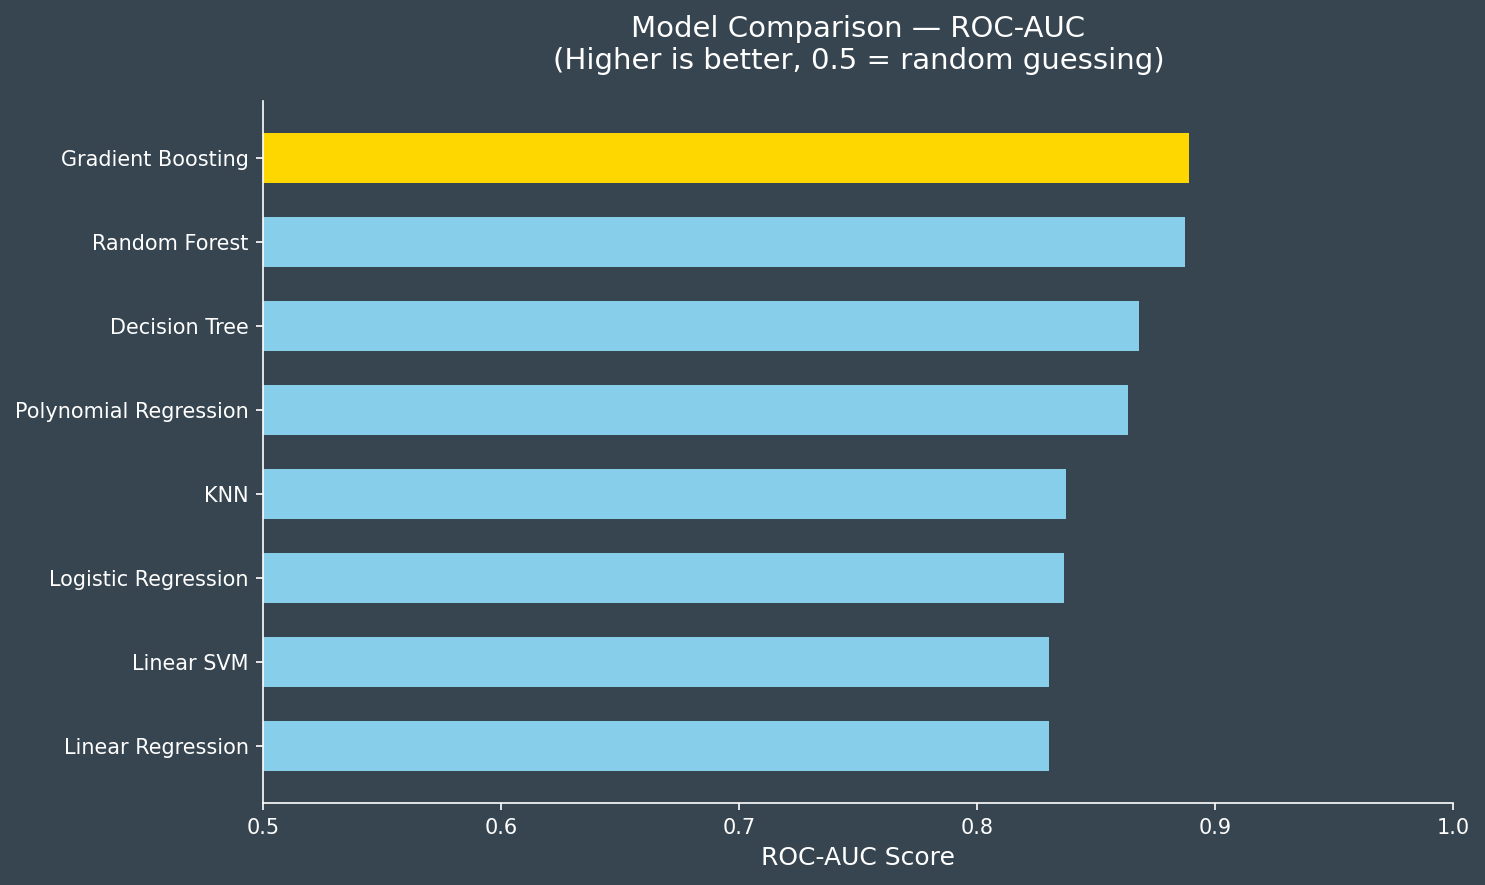

In [16]:
# Minimalist Charcoal Theme with Gold/Sky-Blue accents
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor('#36454F')
ax.set_facecolor('#36454F')

# Color mapping: Gold for the top performer, Sky Blue for the rest
colors = ['#FFD700' if i == 0 else '#87CEEB' for i in range(len(results_df))]

ax.barh(results_df['Model'], results_df['ROC-AUC'], color=colors, height=0.6)

plt.xlabel('ROC-AUC Score', color='white', fontsize=12)
plt.title('Model Comparison — ROC-AUC\n(Higher is better, 0.5 = random guessing)', color='white', pad=15, fontsize=14)
plt.xlim(0.5, 1.0)
ax.invert_yaxis() # Highest score at the top
ax.tick_params(colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/target_distribution_9.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [17]:
# Automatically select the model with the highest ROC-AUC
winner_name = results_df.iloc[0]['Model']
winner_model = fitted_models[winner_name]

print(f"=========================================")
print(f" WINNING MODEL: {winner_name.upper()}")
print(f"=========================================\n")

# Base predictions of the winning model
if hasattr(winner_model, 'predict_proba') or hasattr(winner_model, 'decision_function'):
    base_preds = winner_model.predict(X_test)
else:
    base_preds = (winner_model.predict(X_test) >= 0.5).astype(int)

print(classification_report(y_test, base_preds, target_names=['Paid (0)', 'Default (1)']))

 WINNING MODEL: GRADIENT BOOSTING

              precision    recall  f1-score   support

    Paid (0)       0.76      0.93      0.83      7328
 Default (1)       0.90      0.70      0.79      7328

    accuracy                           0.81     14656
   macro avg       0.83      0.81      0.81     14656
weighted avg       0.83      0.81      0.81     14656



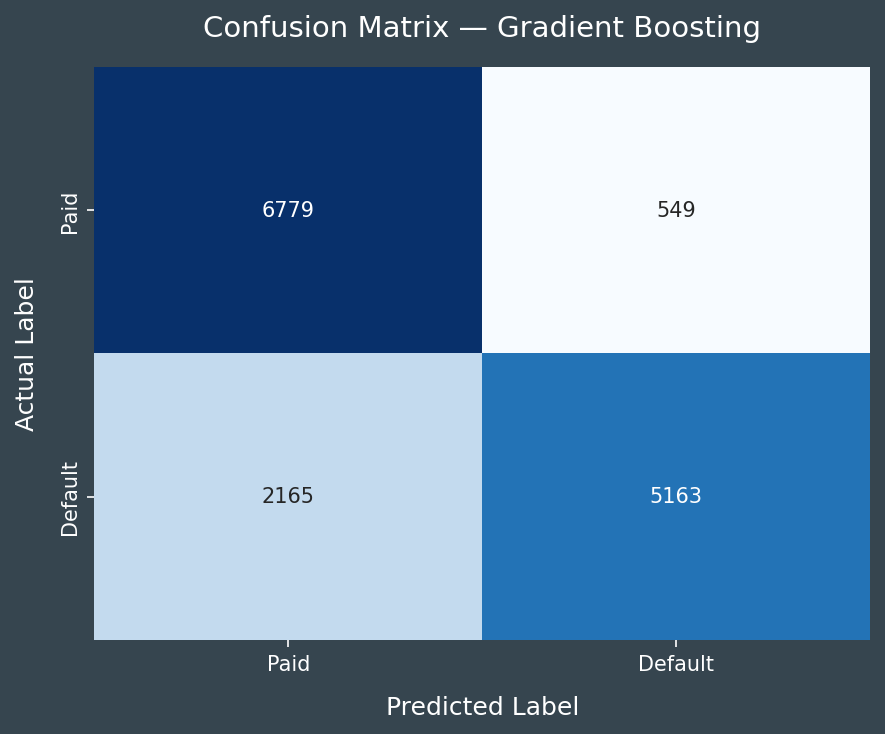

In [18]:
cm = confusion_matrix(y_test, base_preds)

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
fig.patch.set_facecolor('#36454F')

# Using Blues colormap to compliment the sky-blue project theme
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid', 'Default'], 
            yticklabels=['Paid', 'Default'], 
            cbar=False, ax=ax)

plt.xlabel('Predicted Label', color='white', fontsize=12, labelpad=10)
plt.ylabel('Actual Label', color='white', fontsize=12, labelpad=10)
plt.title(f'Confusion Matrix — {winner_name}', color='white', fontsize=14, pad=15)
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('../reports/target_distribution_10.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

In [19]:
def find_best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    # Calculate F1 scores, adding a tiny epsilon to prevent division by zero
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# Extract probabilities/scores based on the algorithm type
if hasattr(winner_model, 'predict_proba'):
    winner_scores = winner_model.predict_proba(X_test)[:, 1]
elif hasattr(winner_model, 'decision_function'):
    winner_scores = winner_model.decision_function(X_test)
else:
    winner_scores = winner_model.predict(X_test)

best_threshold, best_f1 = find_best_threshold(y_test, winner_scores)
print(f"Best tuned threshold: {best_threshold:.3f} (Standard is 0.5)")
print(f"F1 at optimal threshold: {best_f1:.4f}\n")

# Evaluate with the optimized threshold
tuned_preds = (winner_scores >= best_threshold).astype(int)
print("=== CLASSIFICATION REPORT (TUNED THRESHOLD) ===")
print(classification_report(y_test, tuned_preds, target_names=['Paid (0)', 'Default (1)']))

# Save the absolute best pipeline artifacts
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd

joblib.dump(winner_model, PROJECT_ROOT / 'model.pkl')

with open(PROJECT_ROOT / 'model_threshold.json', 'w') as f:
    json.dump({'threshold': float(best_threshold), 'model_name': winner_name}, f)

print(f"\nSUCCESS: Saved 'model.pkl' and 'model_threshold.json' to {PROJECT_ROOT}")

Best tuned threshold: 0.353 (Standard is 0.5)
F1 at optimal threshold: 0.8029

=== CLASSIFICATION REPORT (TUNED THRESHOLD) ===
              precision    recall  f1-score   support

    Paid (0)       0.81      0.79      0.80      7328
 Default (1)       0.80      0.81      0.80      7328

    accuracy                           0.80     14656
   macro avg       0.80      0.80      0.80     14656
weighted avg       0.80      0.80      0.80     14656


SUCCESS: Saved 'model.pkl' and 'model_threshold.json' to c:\Users\krish\Desktop\STProject
